<a href="https://colab.research.google.com/github/catarina1532/avcad/blob/main/avcad_ex4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Prepare the dataset

In [32]:
#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [33]:
#load dataset
df = pd.read_csv('EFIplus_medit.zip', compression='zip', sep=';')

In [34]:
#remove unnecessary columns
df.drop(df.iloc[:,5:15], axis=1, inplace=True)

In [35]:
#rename column
df.rename(columns={'Sum of Run1_number_all':'Total_fish_individuals'}, inplace=True)

In [36]:
#remove missing values
df2 = df.dropna()

##2. Temperature vs Brown Trout

Effect of temperature on Brown Trout (*Salmo trutta fario*) presence by comparing Mean Annual Temperature (Temp_ann) between presence vs absence.

/tmp/ipykernel_442/1219949210.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["Salmo_trutta_fario"] = df2["Salmo trutta fario"].astype("category")
/tmp/ipykernel_442/1219949210.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


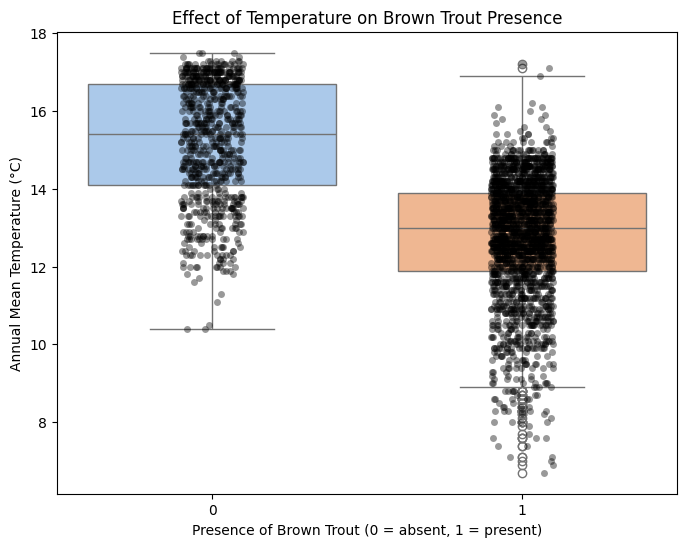

In [37]:
#convert presence to categorical if needed
df2["Salmo_trutta_fario"] = df2["Salmo trutta fario"].astype("category")

plt.figure(figsize=(8,6))

sns.boxplot(
    x="Salmo_trutta_fario",
    y="temp_ann",
    data=df2,
    palette="pastel"
)

sns.stripplot(
    x="Salmo_trutta_fario",
    y="temp_ann",
    data=df2,
    color="black",
    alpha=0.4,
    jitter=True
)

plt.xlabel("Presence of Brown Trout (0 = absent, 1 = present)")
plt.ylabel("Annual Mean Temperature (°C)")
plt.title("Effect of Temperature on Brown Trout Presence")

plt.show()

Box plots and strip plots were used to examine the relationship of annual mean temperature to brown trout. Results indicate that brown trout are primarily found at lower temperatures because median temperature is lower in sites where they are present than in sites where they are absent. However, some overlap exists, indicating that temperature alone is not a sufficient predictor for brown trout presence.

##3. Minho vs Tejo (effect size)

Compare the temperature difference between presence/absence in each catchment.

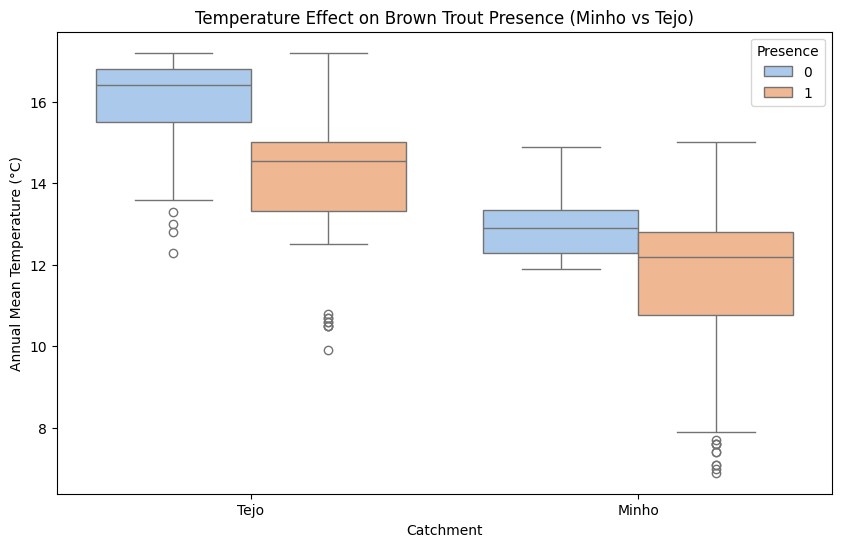

In [38]:
df_sub = df2[df2["Catchment_name"].isin(["Minho", "Tejo"])]

plt.figure(figsize=(10,6))

sns.boxplot(
    x="Catchment_name",
    y="temp_ann",
    hue="Salmo_trutta_fario",
    data=df_sub,
    palette="pastel"
)

plt.xlabel("Catchment")
plt.ylabel("Annual Mean Temperature (°C)")
plt.title("Temperature Effect on Brown Trout Presence (Minho vs Tejo)")

plt.legend(title="Presence")
plt.show()

In [39]:
#effect size
for catchment in ["Minho", "Tejo"]:

    subset = df_sub[df_sub["Catchment_name"] == catchment]

    mean_present = subset[subset["Salmo_trutta_fario"] == 1]["temp_ann"].mean()
    mean_absent = subset[subset["Salmo_trutta_fario"] == 0]["temp_ann"].mean()

    effect_size = mean_present - mean_absent

    print(catchment, "Effect size:", round(effect_size, 2))

Minho Effect size: -1.14
Tejo Effect size: -2.2


In comparisons between Minho and Tejo catchments, the significance of temperature was greater in Tejo (effect size = -2.2) than in Minho (effect size = -1.14), and therefore, temperature is probably a stronger distributing factor of the species in Tejo.

##4. Is actual_river_slope normally distributed?

####**Visualization**

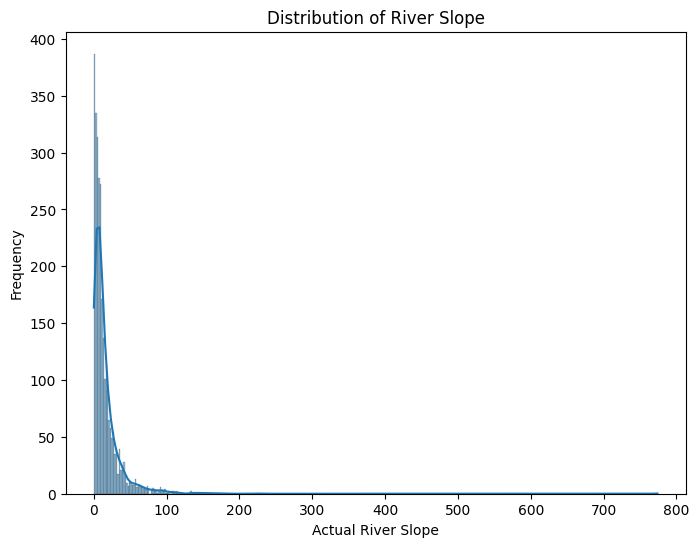

In [40]:
#histogram + KDE
plt.figure(figsize=(8,6))

sns.histplot(df2["Actual_river_slope"], kde=True)

plt.title("Distribution of River Slope")
plt.xlabel("Actual River Slope")
plt.ylabel("Frequency")

plt.show()

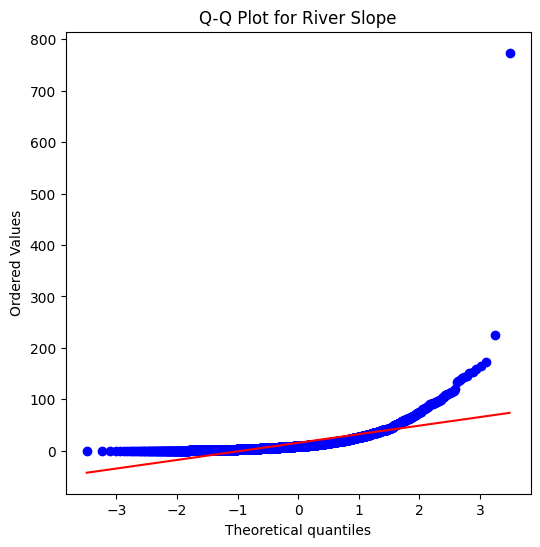

In [41]:
#qq-plot
import scipy.stats as stats

plt.figure(figsize=(6,6))

stats.probplot(df2["Actual_river_slope"], dist="norm", plot=plt)

plt.title("Q-Q Plot for River Slope")
plt.show()

####**Hypothesis**

In [42]:
#Shapiro-Wilk test
from scipy.stats import shapiro

stat, p = shapiro(df2["Actual_river_slope"])  #use the entire column as it's within the recommended sample size

print("p-value:", p)

p-value: 1.0391231937442143e-67


To measure the difference between the actual distribution of river slope and the normal distribution, we used histograms, qq-plots, and the Shapiro-Wilk test. The histogram indicates that the distribution has a strong positive skew while the qq-plot demonstrates a significant departure from the reference line with the most notable deviation occurring in the upper tail. The conclusion of the Shapiro-Wilk test supports this finding (p-value ≈ 1.04 × 10⁻⁶⁷), which resulted in the rejection of the null hypothesis regarding normality of the data; thus, not behaving normally.

##5. Sampling distribution of the mean (CLT)

In [43]:
#generate samples
means = []

for i in range(100):

    sample = df2["Actual_river_slope"].sample(n=2000, replace=True)
    means.append(sample.mean())

means = np.array(means)

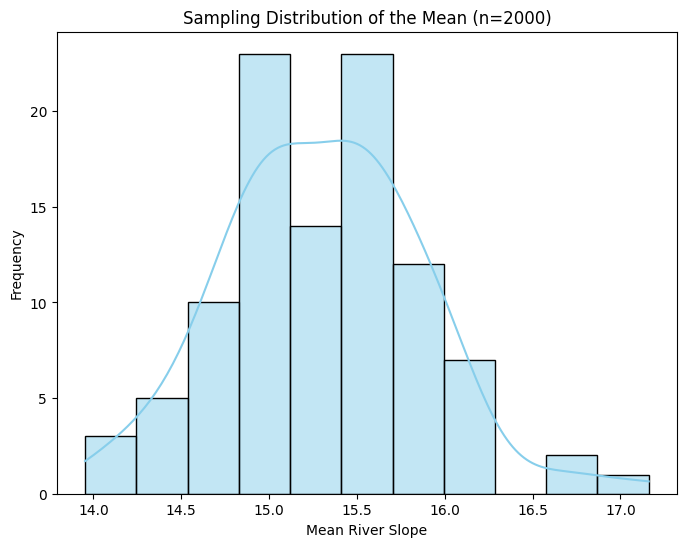

In [44]:
#histogram of means
plt.figure(figsize=(8,6))

sns.histplot(means, kde=True, color="skyblue")

plt.title("Sampling Distribution of the Mean (n=2000)")
plt.xlabel("Mean River Slope")
plt.ylabel("Frequency")

plt.show()

In [45]:
#normality test on means
stat, p = shapiro(means)

print("p-value:", p)

p-value: 0.4884580150904844


However, the mean of the sampling distribution for means of repeated samples of size 2000 appears approximately normally distributed. The Shapiro-Wilk test (p-value = 0.49) does not provide evidence against normality. The Central Limit Theorem (CLT) supports these results, as it posits that the population means of independent random samples will have an asymptotic normal distribution regardless if the population from which they were taken is not normally distributed.

**Conclusion:**

The strong skewness observed in the original variable is supported by both graphical and statistical evidence, while the approximately normal distribution of the sample means (p-value = 0.49) confirms the Central Limit Theorem (CLT) and supports the validity of statistical inference based on the mean.